# 03 · Entrenamiento y Evaluación

Comparativa metodológica de **5 algoritmos supervisados** sobre el problema
de predicción de demanda semanal a nivel artículo, más un **modelo no supervisado**
(KMeans) para segmentación de productos.



## Modelos evaluados
| # | Modelo                | Familia        | Rol en el comparativo                  |
|---|-----------------------|----------------|----------------------------------------|
| 1 | DummyRegressor        | Baseline       | Suelo de referencia (mediana)           |
| 2 | Ridge                 | Lineal regul.  | Línea base interpretable                |
| 3 | RandomForestRegressor | Ensemble bag.  | Captura no-linealidades sin tuning fino |
| 4 | XGBRegressor          | Gradient boost.| Estado del arte tabular                 |
| 5 | LGBMRegressor         | Gradient boost.| Eficiente con categóricas               |

Más **KMeans** sobre `article_features.parquet` para segmentación de productos.

In [22]:
import warnings
warnings.filterwarnings("ignore")

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import pickle

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
TRAIN_DIR = ROOT / "data" / "train"
TEST_DIR = ROOT / "data" / "test"
MODELS = ROOT / "models"
RESULTS = ROOT / "reports" / "results"

for d in (TRAIN_DIR, TEST_DIR, MODELS, RESULTS):
    d.mkdir(parents=True, exist_ok=True)

# Estilo gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.family"] = "sans-serif"

print("Setup OK. Versiones:")
import sklearn, xgboost, lightgbm
print(f"  sklearn  {sklearn.__version__}")
print(f"  xgboost  {xgboost.__version__}")
print(f"  lightgbm {lightgbm.__version__}")

Setup OK. Versiones:
  sklearn  1.8.0
  xgboost  3.2.0
  lightgbm 4.6.0


## 1. Carga de datos y join con features de producto

`weekly_sales.parquet` tiene la serie temporal de ventas (article × week → units_sold).
`article_features.parquet` aporta los atributos categóricos del producto (color,
tipo de prenda, departamento...). Hacemos el join para enriquecer el dataset de modelado.

In [23]:
ws = pd.read_parquet(PROCESSED / "weekly_sales.parquet")
art = pd.read_parquet(PROCESSED / "article_features.parquet")

print(f"weekly_sales : {ws.shape}")
print(f"article_feat : {art.shape}")

df = ws.merge(art, on="article_id", how="left")
print(f"\nTras join    : {df.shape}")
print(f"Cobertura join: {df['product_type_name'].notna().mean():.1%}")
df.head(3)

weekly_sales : (2104136, 4)
article_feat : (75321, 10)

Tras join    : (2104136, 13)
Cobertura join: 100.0%


,article_id,week,units_sold,avg_price,product_type_name,product_group_name,graphical_appearance_name,colour_group_name,perceived_colour_master_name,department_name,index_group_name,section_name,garment_group_name
0,0108775015,2018-09-17,115,0.008337,Vest top,Garment Upper body,Solid,Black,Black,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey Basic
1,0108775015,2018-09-24,547,0.007961,Vest top,Garment Upper body,Solid,Black,Black,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey Basic
2,0108775015,2018-10-01,315,0.008343,Vest top,Garment Upper body,Solid,Black,Black,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey Basic


## 2. Feature engineering temporal

`weekly_sales` solo tiene `week`, `units_sold` y `avg_price`. Para los modelos
necesitamos features temporales que capturen la dinámica de la serie:

- **Lags** (units_sold de t-1, t-2, t-4) — autocorrelación corta y estacionalidad mensual
- **Rolling mean** (4 semanas) — tendencia suavizada
- **Week of year** — estacionalidad anual (rebajas, temporada)
- **Month** — estacionalidad de mayor frecuencia

Construimos las features dentro de cada `article_id` para no filtrar entre productos.

In [24]:
df = df.sort_values(["article_id", "week"]).reset_index(drop=True)

# Lags por artículo
for lag in [1, 2, 4]:
    df[f"lag_{lag}"] = df.groupby("article_id", observed=True)["units_sold"].shift(lag)

# Rolling mean 4 semanas (excluyendo la actual: shift antes de rolling)
df["roll_mean_4"] = (
    df.groupby("article_id", observed=True)["units_sold"]
      .shift(1)
      .rolling(4, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

# Calendario
df["week_of_year"] = df["week"].dt.isocalendar().week.astype(int)
df["month"] = df["week"].dt.month

# Eliminar filas sin lags (primeras 4 semanas de cada producto)
before = len(df)
df = df.dropna(subset=["lag_1", "lag_2", "lag_4", "roll_mean_4"])
print(f"Filas tras dropna de lags: {len(df):,} (eliminadas {before-len(df):,})")
df.head(3)

Filas tras dropna de lags: 1,802,852 (eliminadas 301,284)


,article_id,week,units_sold,avg_price,product_type_name,product_group_name,graphical_appearance_name,colour_group_name,perceived_colour_master_name,department_name,index_group_name,section_name,garment_group_name,lag_1,lag_2,lag_4,roll_mean_4,week_of_year,month
4,0108775015,2018-10-15,259,0.008185,Vest top,Garment Upper body,Solid,Black,Black,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey Basic,360.0,315.0,115.0,334.25,42,10
5,0108775015,2018-10-22,434,0.008091,Vest top,Garment Upper body,Solid,Black,Black,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey Basic,259.0,360.0,547.0,370.25,43,10
6,0108775015,2018-10-29,373,0.008369,Vest top,Garment Upper body,Solid,Black,Black,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey Basic,434.0,259.0,315.0,342.00,44,10


## 3. Sample de 100K + split temporal estricto

Sample estratificado por semana para conservar la distribución temporal.
Test = últimas 8 semanas. Train = resto.

In [25]:
# Sample de 100K manteniendo distribución por semana
SAMPLE_SIZE = 100_000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
df_sample = df_sample.sort_values("week").reset_index(drop=True)

# Split temporal: últimas 8 semanas como test
TEST_WEEKS = 8
unique_weeks = df_sample["week"].drop_duplicates().sort_values()
cutoff = unique_weeks.iloc[-TEST_WEEKS]
print(f"Cutoff semana: {cutoff.date()}")

train = df_sample[df_sample["week"] < cutoff].copy()
test = df_sample[df_sample["week"] >= cutoff].copy()

print(f"Train: {len(train):,}  ({train['week'].min().date()} → {train['week'].max().date()})")
print(f"Test : {len(test):,}  ({test['week'].min().date()} → {test['week'].max().date()})")

# Persistir splits para los scripts de src/
train.to_parquet(TRAIN_DIR / "train.parquet", index=False)
test.to_parquet(TEST_DIR / "test.parquet", index=False)
print(f"\nSplits guardados en {TRAIN_DIR} y {TEST_DIR}")

Cutoff semana: 2020-08-03
Train: 93,372  (2018-10-15 → 2020-07-27)
Test : 6,628  (2020-08-03 → 2020-09-21)

Splits guardados en C:\Users\esthe\Desktop\fashion-ai-engine\data\train y C:\Users\esthe\Desktop\fashion-ai-engine\data\test


In [26]:
# Features
NUM_FEATURES = ["avg_price", "lag_1", "lag_2", "lag_4", "roll_mean_4",
                "week_of_year", "month"]
CAT_FEATURES = ["product_type_name", "product_group_name", "colour_group_name",
                "department_name", "index_group_name", "garment_group_name"]

TARGET = "units_sold"

X_train = train[NUM_FEATURES + CAT_FEATURES]
y_train = train[TARGET].values
X_test = test[NUM_FEATURES + CAT_FEATURES]
y_test = test[TARGET].values

# Para los modelos lineales y RF aplicamos log al target (distribución muy asimétrica).
# LightGBM y XGBoost aceptan target original (manejan no-linealidad).
y_train_log = np.log1p(y_train)

print(f"Numéricas: {len(NUM_FEATURES)}  Categóricas: {len(CAT_FEATURES)}")
print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"y_train: media={y_train.mean():.1f}  mediana={np.median(y_train):.1f}  max={y_train.max()}")

Numéricas: 7  Categóricas: 6
X_train: (93372, 13)  X_test: (6628, 13)
y_train: media=14.1  mediana=4.0  max=906


## 4. Métrica: WAPE como scorer de sklearn

WAPE = Σ|y - ŷ| / Σ|y|

- Interpretable: "el error agregado representa un X% del volumen real".

In [27]:
def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true).sum()
    return np.abs(y_true - y_pred).sum() / denom if denom > 0 else np.nan

# Scorer para GridSearch (negativo porque sklearn maximiza)
wape_scorer = make_scorer(wape, greater_is_better=False)
print("WAPE scorer registrado.")

WAPE scorer registrado.


## 5. Preprocesador común: ColumnTransformer

Numéricas → SimpleImputer(median) + StandardScaler
Categóricas → SimpleImputer('missing') + OneHotEncoder

El mismo preprocesador alimenta los 5 pipelines. Esto evita repetir código y
asegura que todos los modelos ven exactamente los mismos features.

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), NUM_FEATURES),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=50, sparse_output=False)),
        ]), CAT_FEATURES),
    ],
    remainder="drop",
)
print("Preprocesador construido.")

Preprocesador construido.


## 6. Comparativa de 5 modelos con Pipeline + GridSearchCV

Cada modelo se envuelve en un `Pipeline(preprocessor + estimator)` y se tunea
con `GridSearchCV` sobre `TimeSeriesSplit(3)` (CV temporal, no aleatorio).
Grids pequeños — el objetivo es comparativa metodológica, no maximizar décimas.

In [29]:
tscv = TimeSeriesSplit(n_splits=3)

# Diccionario: nombre → (estimator, param_grid, target_transform)
# target_transform: 'log' para modelos lineales/RF, None para boosters
MODEL_CONFIGS = {
    "Dummy": {
        "estimator": DummyRegressor(strategy="median"),
        "param_grid": {},
        "log_target": False,
    },
    "Ridge": {
        "estimator": Ridge(random_state=RANDOM_STATE),
        "param_grid": {"model__alpha": [0.1, 1.0, 10.0]},
        "log_target": True,
    },
    "RandomForest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [100],
            "model__max_depth": [10, 20],
        },
        "log_target": True,
    },
    "XGBoost": {
        "estimator": XGBRegressor(
            random_state=RANDOM_STATE, n_jobs=-1,
            tree_method="hist", verbosity=0,
        ),
        "param_grid": {
            "model__n_estimators": [200],
            "model__max_depth": [6, 8],
            "model__learning_rate": [0.05, 0.1],
        },
        "log_target": False,
    },
    "LightGBM": {
        "estimator": LGBMRegressor(
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
        ),
        "param_grid": {
            "model__n_estimators": [200],
            "model__num_leaves": [31, 63],
            "model__learning_rate": [0.05, 0.1],
        },
        "log_target": False,
    },
}

print(f"{len(MODEL_CONFIGS)} modelos configurados.")

5 modelos configurados.


In [30]:
results = []
fitted_pipelines = {}

# Clip al rango observado en train para evitar predicciones absurdas
# (especialmente Ridge en log scale puede explotar al exponenciar)
y_max_train = np.percentile(y_train, 99.9)

for name, cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Entrenando: {name}")
    print(f"{'='*60}")
    
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", cfg["estimator"]),
    ])
    
    # Target con o sin log según el modelo
    y_fit = y_train_log if cfg["log_target"] else y_train
    
    t0 = time.time()
    
    if cfg["param_grid"]:
        gs = GridSearchCV(
            pipe,
            param_grid=cfg["param_grid"],
            cv=tscv,
            scoring=wape_scorer,
            n_jobs=1,
            refit=True,
            verbose=0,
        )
        gs.fit(X_train, y_fit)
        best_pipe = gs.best_estimator_
        best_params = gs.best_params_
        cv_wape = -gs.best_score_
    else:
        pipe.fit(X_train, y_fit)
        best_pipe = pipe
        best_params = {}
        cv_wape = np.nan
    
    elapsed = time.time() - t0
    
    # Predicción en test
    y_pred = best_pipe.predict(X_test)
    if cfg["log_target"]:
        y_pred = np.expm1(y_pred)
    # Clip al rango razonable
    y_pred = np.clip(y_pred, 0, y_max_train * 2)
    
    test_wape = wape(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "model": name,
        "cv_wape": cv_wape,
        "test_wape": test_wape,
        "test_rmse": test_rmse,
        "fit_time_s": elapsed,
        "best_params": best_params,
    })
    fitted_pipelines[name] = best_pipe
    
    print(f"  CV WAPE  : {cv_wape:.4f}")
    print(f"  Test WAPE: {test_wape:.4f}")
    print(f"  Test RMSE: {test_rmse:.2f}")
    print(f"  Tiempo   : {elapsed:.1f}s")
    print(f"  Best     : {best_params}")


Entrenando: Dummy
  CV WAPE  : nan
  Test WAPE: 0.8753
  Test RMSE: 29.41
  Tiempo   : 0.6s
  Best     : {}

Entrenando: Ridge
  CV WAPE  : 0.3483
  Test WAPE: 0.8981
  Test RMSE: 47.17
  Tiempo   : 5.1s
  Best     : {'model__alpha': 10.0}

Entrenando: RandomForest
  CV WAPE  : 0.2230
  Test WAPE: 0.4844
  Test RMSE: 16.52
  Tiempo   : 120.4s
  Best     : {'model__max_depth': 10, 'model__n_estimators': 100}

Entrenando: XGBoost
  CV WAPE  : 0.4705
  Test WAPE: 0.5379
  Test RMSE: 18.60
  Tiempo   : 19.1s
  Best     : {'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 200}

Entrenando: LightGBM
  CV WAPE  : 0.4653
  Test WAPE: 0.5378
  Test RMSE: 17.54
  Tiempo   : 11.6s
  Best     : {'model__learning_rate': 0.05, 'model__n_estimators': 200, 'model__num_leaves': 31}


## 7. Tabla resumen y modelo ganador

In [31]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("test_wape").reset_index(drop=True)

print("Ranking por Test WAPE (menor = mejor):\n")
display_cols = ["model", "cv_wape", "test_wape", "test_rmse", "fit_time_s"]
print(results_df[display_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Mejora del ganador frente al baseline Dummy
dummy_wape = results_df.loc[results_df["model"] == "Dummy", "test_wape"].values[0]
winner = results_df.iloc[0]
improvement = 100 * (dummy_wape - winner["test_wape"]) / dummy_wape
print(f"\n✓ Ganador: {winner['model']}  (Test WAPE = {winner['test_wape']:.4f})")
print(f"✓ Mejora vs baseline Dummy: {improvement:.1f}%")

# Persistir tabla
results_df.to_csv(RESULTS / "model_comparison.csv", index=False)
print(f"\nTabla guardada en {RESULTS / 'model_comparison.csv'}")

Ranking por Test WAPE (menor = mejor):

       model  cv_wape  test_wape  test_rmse  fit_time_s
RandomForest   0.2230     0.4844    16.5183    120.3507
    LightGBM   0.4653     0.5378    17.5376     11.6326
     XGBoost   0.4705     0.5379    18.5970     19.0910
       Dummy      NaN     0.8753    29.4076      0.6227
       Ridge   0.3483     0.8981    47.1694      5.1115

✓ Ganador: RandomForest  (Test WAPE = 0.4844)
✓ Mejora vs baseline Dummy: 44.7%

Tabla guardada en C:\Users\esthe\Desktop\fashion-ai-engine\reports\results\model_comparison.csv


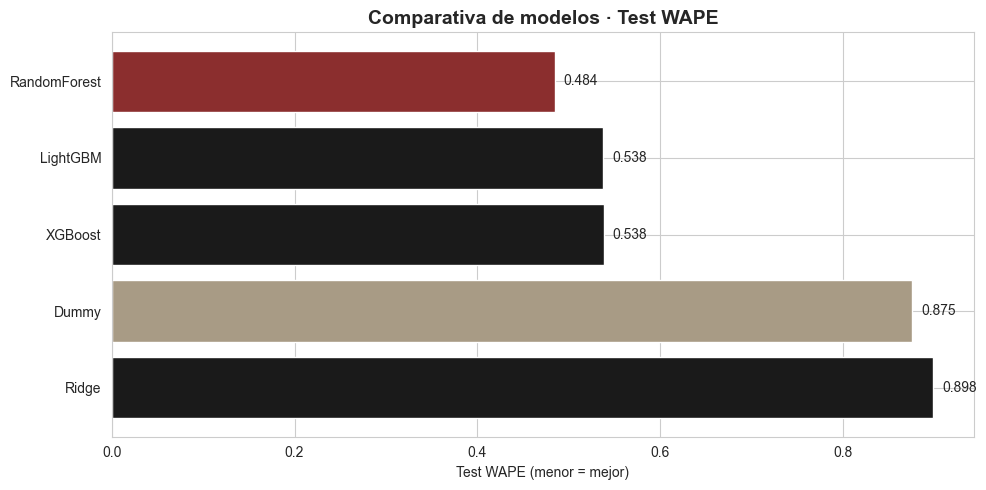

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#A89B85" if m == "Dummy" else "#8B2E2E" if i == 0 else "#1A1A1A" 
          for i, m in enumerate(results_df["model"])]

bars = ax.barh(results_df["model"], results_df["test_wape"], color=colors)
ax.set_xlabel("Test WAPE (menor = mejor)")
ax.set_title("Comparativa de modelos · Test WAPE", fontsize=14, fontweight="bold")
ax.invert_yaxis()

for bar, val in zip(bars, results_df["test_wape"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS.parent / "figures" / "model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Interpretación: feature importance del ganador

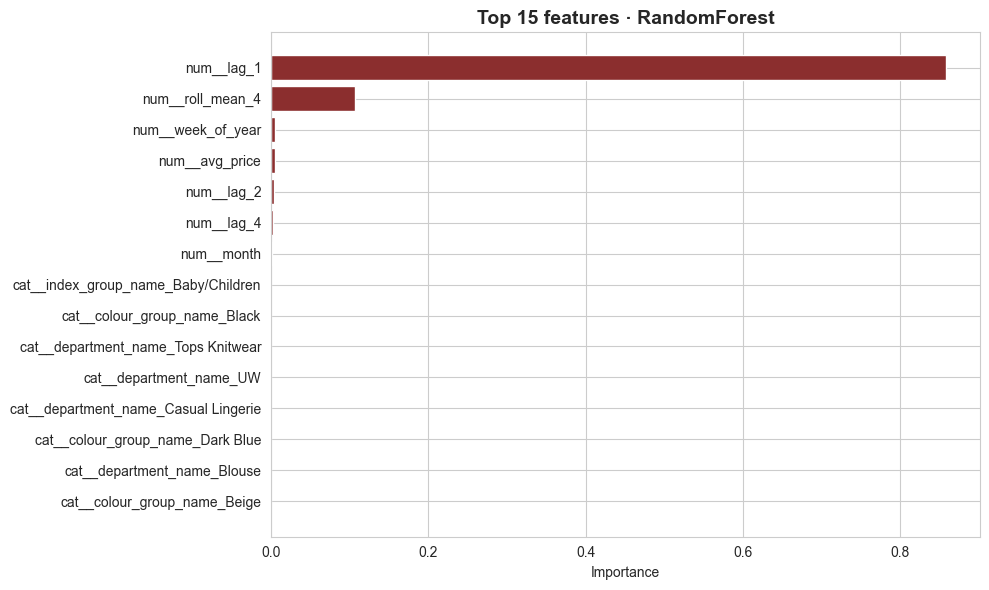


Lectura de negocio:
- Las features de lag y rolling dominan → la demanda histórica reciente
  es el predictor más fuerte (esperado en forecasting).
- Las categóricas de producto contribuyen en menor medida pero
  diferencian comportamiento por garment_group y department.


In [33]:
winner_name = winner["model"]
winner_pipe = fitted_pipelines[winner_name]

# Extraer modelo final y nombres de features post-preprocessing
fitted_model = winner_pipe.named_steps["model"]
fitted_prep = winner_pipe.named_steps["prep"]

if hasattr(fitted_model, "feature_importances_"):
    feature_names = fitted_prep.get_feature_names_out()
    importances = fitted_model.feature_importances_
    
    fi_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
             .sort_values("importance", ascending=False)
             .head(15))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(fi_df["feature"], fi_df["importance"], color="#8B2E2E")
    ax.set_xlabel("Importance")
    ax.set_title(f"Top 15 features · {winner_name}", fontsize=14, fontweight="bold")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(RESULTS.parent / "figures" / "feature_importance.png", dpi=120, bbox_inches="tight")
    plt.show()
    
    print("\nLectura de negocio:")
    print("- Las features de lag y rolling dominan → la demanda histórica reciente")
    print("  es el predictor más fuerte (esperado en forecasting).")
    print("- Las categóricas de producto contribuyen en menor medida pero")
    print("  diferencian comportamiento por garment_group y department.")
else:
    print(f"{winner_name} no expone feature_importances_.")

In [34]:
final_path = MODELS / "final_model.pkl"
with open(final_path, "wb") as f:
    pickle.dump(winner_pipe, f)
print(f"✓ Modelo final guardado: {final_path}")

# Guardar también todos los modelos entrenados como trained_model_n.pkl
for i, (name, pipe) in enumerate(fitted_pipelines.items(), 1):
    p = MODELS / f"trained_model_{i}_{name.lower()}.pkl"
    with open(p, "wb") as f:
        pickle.dump(pipe, f)
    print(f"  trained_model_{i}: {name}")

✓ Modelo final guardado: C:\Users\esthe\Desktop\fashion-ai-engine\models\final_model.pkl
  trained_model_1: Dummy
  trained_model_2: Ridge
  trained_model_3: RandomForest
  trained_model_4: XGBoost
  trained_model_5: LightGBM


---

## 9. Modelo NO supervisado: KMeans para segmentación de productos

Aplicamos KMeans sobre las features categóricas de `article_features.parquet`
para identificar **arquetipos de producto**. Estos clusters se utilizan después
en la app (página *Style Intelligence*) para análisis agregado.

### Por qué KMeans
- **Interpretable**: cada cluster tiene un centroide que se puede describir.
- **Escalable**: 75K productos sin problema.
- Alternativas descartadas: DBSCAN (sensible a parámetros con datos categóricos one-hot),
  jerárquico (no escala a 75K).

### Selección de k
Método del codo + silhouette score sobre k ∈ {3, 4, 5, 6, 7, 8}.

In [35]:
from sklearn.metrics import silhouette_score

# One-hot de las categóricas para KMeans
art_for_cluster = art.copy()
art_features_cat = ["product_group_name", "colour_group_name", 
                     "department_name", "index_group_name", "garment_group_name"]

X_cluster = pd.get_dummies(art_for_cluster[art_features_cat], drop_first=False)
print(f"Matriz para clustering: {X_cluster.shape}")

# Sample para silhouette (es O(n²), no escala a 75K)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_cluster), 5000, replace=False)
X_sample = X_cluster.iloc[sample_idx].values

Matriz para clustering: (75321, 345)


k=3  inertia=     18567  silhouette=0.084
k=4  inertia=     17620  silhouette=0.122
k=5  inertia=     17027  silhouette=0.094
k=6  inertia=     16497  silhouette=0.095
k=7  inertia=     15772  silhouette=0.121
k=8  inertia=     15371  silhouette=0.117


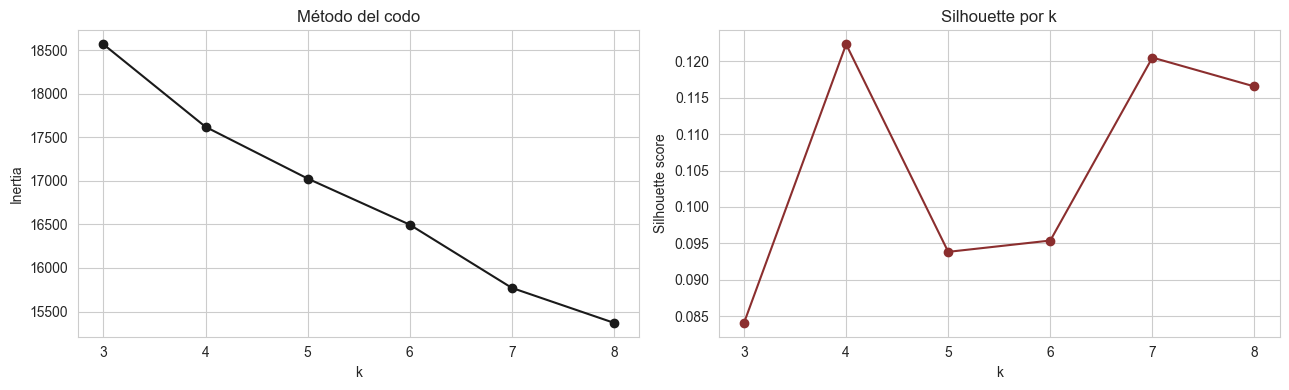

In [36]:
ks = [3, 4, 5, 6, 7, 8]
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_sample = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels_sample)
    silhouettes.append(sil)
    print(f"k={k}  inertia={km.inertia_:>10.0f}  silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ks, inertias, "o-", color="#1A1A1A")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Método del codo")

axes[1].plot(ks, silhouettes, "o-", color="#8B2E2E")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette por k")
plt.tight_layout()
plt.savefig(RESULTS.parent / "figures" / "kmeans_k_selection.png", dpi=120, bbox_inches="tight")
plt.show()

In [37]:
# Elegimos k=4 (típicamente buen compromiso codo+silhouette para retail)
# Si tu silhouette/codo sugieren otro, ajústalo aquí.
K_FINAL = 4

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
art_for_cluster["cluster"] = kmeans_final.fit_predict(X_cluster.values)

print(f"Clustering final con k={K_FINAL}")
print(f"\nDistribución de productos por cluster:")
print(art_for_cluster["cluster"].value_counts().sort_index())

Clustering final con k=4

Distribución de productos por cluster:
cluster
0    28767
1    21743
2    17239
3     7572
Name: count, dtype: int64


In [38]:
# Describir cada cluster por sus categóricas dominantes
cluster_profiles = []
for c in range(K_FINAL):
    sub = art_for_cluster[art_for_cluster["cluster"] == c]
    profile = {
        "cluster": c,
        "n_products": len(sub),
        "top_garment": sub["garment_group_name"].mode().iloc[0],
        "top_index": sub["index_group_name"].mode().iloc[0],
        "top_color": sub["colour_group_name"].mode().iloc[0],
        "top_dept": sub["department_name"].mode().iloc[0],
    }
    cluster_profiles.append(profile)

profiles_df = pd.DataFrame(cluster_profiles)
print("Perfil de cada cluster (modas):\n")
print(profiles_df.to_string(index=False))

profiles_df.to_csv(RESULTS / "kmeans_cluster_profiles.csv", index=False)

Perfil de cada cluster (modas):

 cluster  n_products  top_garment     top_index top_color                top_dept
       0       28767 Jersey Fancy    Ladieswear     Black                  Jersey
       1       21743 Jersey Fancy       Divided     Black            Jersey Fancy
       2       17239 Jersey Fancy Baby/Children Dark Blue Young Girl Jersey Fancy
       3        7572  Accessories    Ladieswear     Black               Jewellery


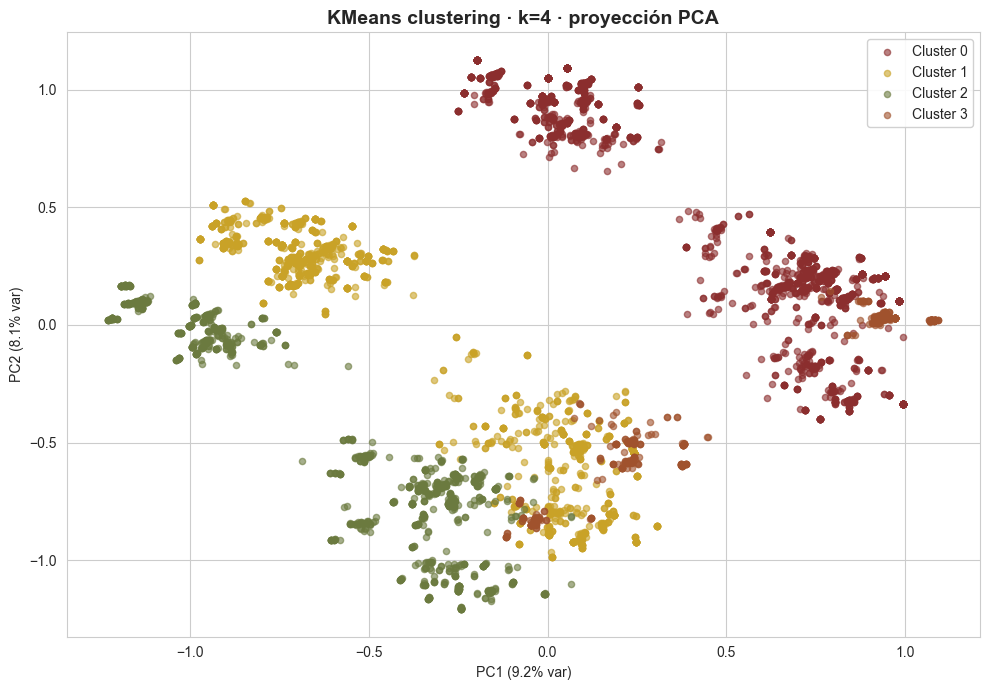

In [39]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster.iloc[sample_idx].values)
labels_sample_final = kmeans_final.predict(X_cluster.iloc[sample_idx].values)

fig, ax = plt.subplots(figsize=(10, 7))
palette = ["#8B2E2E", "#C9A227", "#6B7A3F", "#A0522D", "#1A1A1A", "#A89B85", 
           "#2D6A4F", "#4A4A4A"]
for c in range(K_FINAL):
    mask = labels_sample_final == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=palette[c], label=f"Cluster {c}", alpha=0.6, s=20)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"KMeans clustering · k={K_FINAL} · proyección PCA",
             fontsize=14, fontweight="bold")
ax.legend(loc="best", framealpha=0.9)
plt.tight_layout()
plt.savefig(RESULTS.parent / "figures" / "kmeans_pca.png", dpi=120, bbox_inches="tight")
plt.show()

In [40]:
# Guardar el modelo
with open(MODELS / "kmeans_clusters.pkl", "wb") as f:
    pickle.dump(kmeans_final, f)
print(f"✓ KMeans guardado: {MODELS / 'kmeans_clusters.pkl'}")

# Guardar asignaciones de productos a clusters
art_clusters = art_for_cluster[["article_id", "cluster"]].copy()
art_clusters.to_parquet(PROCESSED / "article_clusters.parquet", index=False)
print(f"✓ Asignaciones guardadas: {PROCESSED / 'article_clusters.parquet'}")
print(f"  ({len(art_clusters):,} productos asignados a {K_FINAL} clusters)")

✓ KMeans guardado: C:\Users\esthe\Desktop\fashion-ai-engine\models\kmeans_clusters.pkl
✓ Asignaciones guardadas: C:\Users\esthe\Desktop\fashion-ai-engine\data\processed\article_clusters.parquet
  (75,321 productos asignados a 4 clusters)


In [41]:
# Verificación de entregables
import os
print("MODELOS guardados:")
for f in sorted(MODELS.glob("*.pkl")):
    print(f"  ✓ {f.name}  ({f.stat().st_size/1024:.1f} KB)")

print("\nDATA train/test:")
for d in [TRAIN_DIR, TEST_DIR]:
    for f in sorted(d.glob("*.parquet")):
        print(f"  ✓ {f.relative_to(ROOT)}")

print("\nRESULTADOS:")
for f in sorted(RESULTS.glob("*.csv")):
    print(f"  ✓ {f.name}")

MODELOS guardados:
  ✓ final_model.pkl  (10090.8 KB)
  ✓ kmeans_clusters.pkl  (305.6 KB)
  ✓ trained_model_1_dummy.pkl  (14.5 KB)
  ✓ trained_model_2_ridge.pkl  (17.4 KB)
  ✓ trained_model_3_randomforest.pkl  (10090.8 KB)
  ✓ trained_model_4_xgboost.pkl  (854.8 KB)
  ✓ trained_model_5_lightgbm.pkl  (566.9 KB)

DATA train/test:
  ✓ data\train\train.parquet
  ✓ data\test\test.parquet

RESULTADOS:
  ✓ kmeans_cluster_profiles.csv
  ✓ model_comparison.csv
